In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

# Go to project root
os.chdir('C:/Users/HomePC/Documents/kifiya/news-sentiment-analysis')

plt.style.use('ggplot')

# Load data
stock_df = pd.read_csv('data/raw/stock_prices_clean.csv', parse_dates=['Date'])
print(f"Loaded {len(stock_df)} rows")
print(f"Stocks: {stock_df['Symbol'].unique().tolist()}")
print(stock_df.head(3))

Loaded 2510 rows
Stocks: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'TSLA', 'JPM', 'BAC', 'WMT', 'PFE']
        Date       Close        High         Low        Open    Volume Symbol
0 2025-05-15  210.614441  212.118484  208.711985  210.116417  45029500   AAPL
1 2025-05-16  210.425201  211.730038  208.941099  211.520861  54737900   AAPL
2 2025-05-19  207.955002  208.652233  203.452858  207.088445  46140500   AAPL


In [9]:
def sma(data, period):
    return data.rolling(window=period).mean()

def ema(data, period):
    return data.ewm(span=period, adjust=False).mean()

def rsi(data, period=14):
    delta = data.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/period, adjust=False).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

def macd(data, fast=12, slow=26, signal=9):
    ema_fast = data.ewm(span=fast, adjust=False).mean()
    ema_slow = data.ewm(span=slow, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    histogram = macd_line - signal_line
    return macd_line, signal_line, histogram

print("✅ Helper functions ready")

✅ Helper functions ready


In [10]:
symbol = 'AAPL'
df = stock_df[stock_df['Symbol'] == symbol].copy()
df = df.sort_values('Date').reset_index(drop=True)

df['SMA_20'] = sma(df['Close'], 20)
df['SMA_50'] = sma(df['Close'], 50)
df['EMA_20'] = ema(df['Close'], 20)
df['RSI'] = rsi(df['Close'], 14)
df['MACD'], df['MACD_Signal'], df['MACD_Hist'] = macd(df['Close'])

print(f"{symbol}: {len(df)} days")
print(df[['Date', 'Close', 'SMA_20', 'RSI']].tail(5))

AAPL: 251 days
          Date       Close      SMA_20        RSI
246 2026-05-08  293.050018  272.960016  72.941202
247 2026-05-11  292.679993  274.645944  72.360729
248 2026-05-12  294.799988  276.456357  73.654347
249 2026-05-13  298.869995  278.090619  75.978793
250 2026-05-14  298.209991  279.843242  74.825876


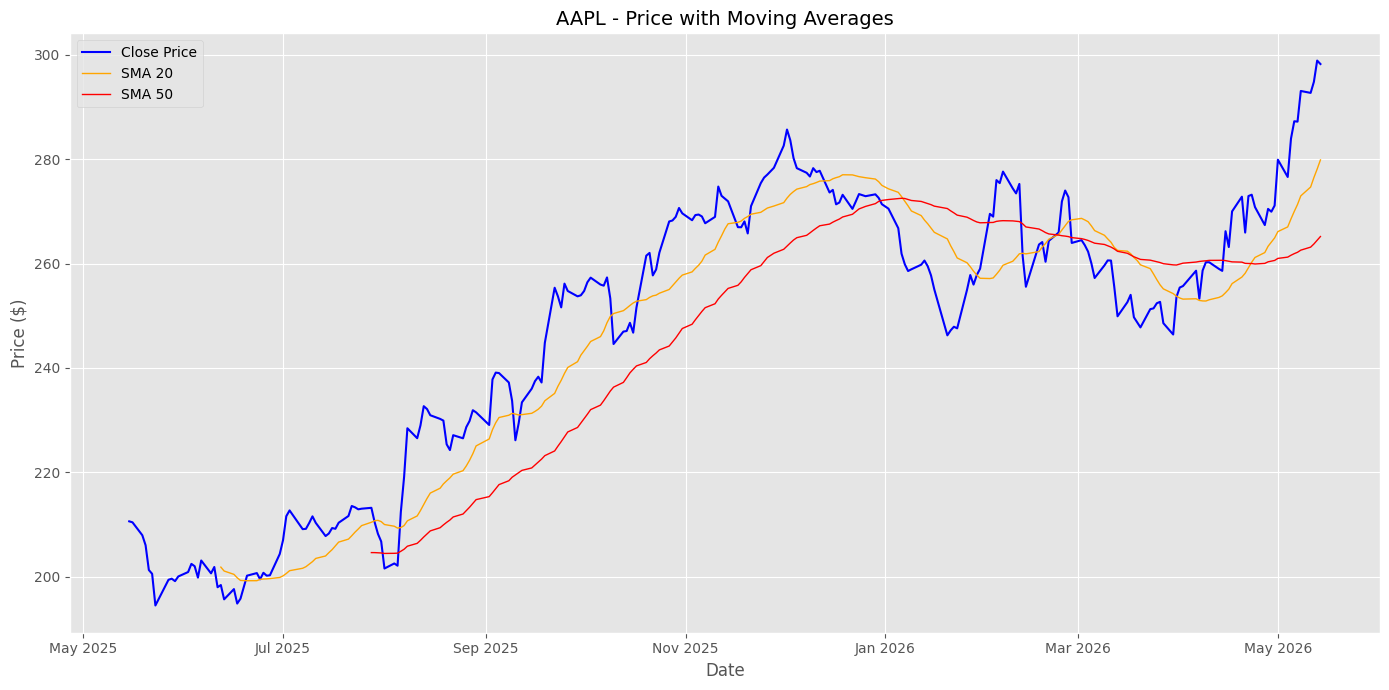

In [11]:
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(df['Date'], df['Close'], label='Close Price', linewidth=1.5, color='blue')
ax.plot(df['Date'], df['SMA_20'], label='SMA 20', linewidth=1, color='orange')
ax.plot(df['Date'], df['SMA_50'], label='SMA 50', linewidth=1, color='red')

ax.set_title(f'{symbol} - Price with Moving Averages', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Price ($)')
ax.legend(loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.show()

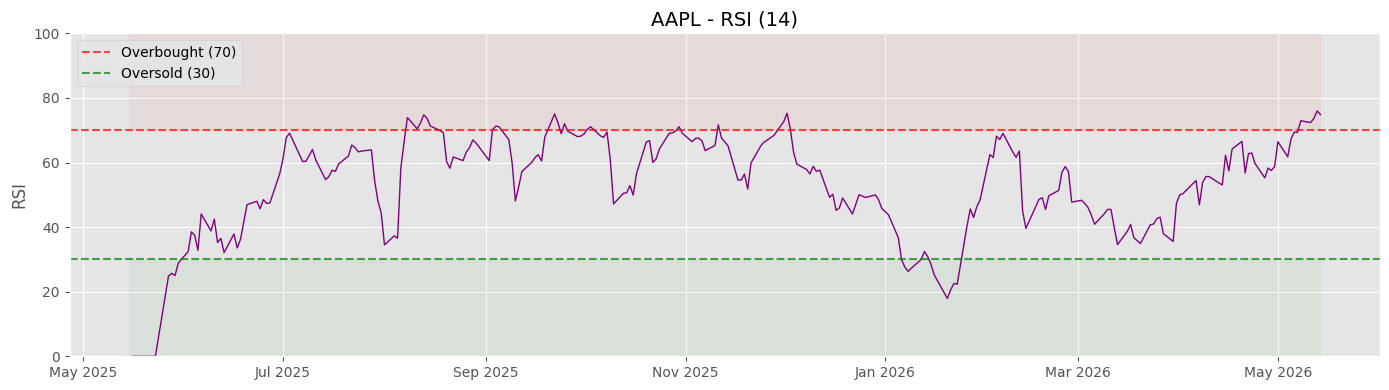

In [12]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df['Date'], df['RSI'], color='purple', linewidth=1)
ax.axhline(70, color='red', linestyle='--', alpha=0.7, label='Overbought (70)')
ax.axhline(30, color='green', linestyle='--', alpha=0.7, label='Oversold (30)')
ax.fill_between(df['Date'], 70, 100, color='red', alpha=0.05)
ax.fill_between(df['Date'], 0, 30, color='green', alpha=0.05)

ax.set_title(f'{symbol} - RSI (14)', fontsize=14)
ax.set_ylabel('RSI')
ax.set_ylim(0, 100)
ax.legend(loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.show()

In [13]:
latest = df.iloc[-1]
print(f"=== {symbol} - {latest['Date'].date()} ===")
print(f"Close: ${latest['Close']:.2f}")
print(f"SMA 20: ${latest['SMA_20']:.2f} | SMA 50: ${latest['SMA_50']:.2f}")
print(f"RSI: {latest['RSI']:.1f}")
print(f"MACD: {latest['MACD']:.3f} | Signal: {latest['MACD_Signal']:.3f}")

if latest['RSI'] > 70:
    print("RSI: OVERBOUGHT - Sell signal")
elif latest['RSI'] < 30:
    print("RSI: OVERSOLD - Buy signal")
else:
    print("RSI: Neutral")

if latest['SMA_20'] > latest['SMA_50']:
    print("MA: BULLISH (SMA20 > SMA50)")
else:
    print("MA: BEARISH (SMA20 < SMA50)")

=== AAPL - 2026-05-14 ===
Close: $298.21
SMA 20: $279.84 | SMA 50: $265.17
RSI: 74.8
MACD: 9.210 | Signal: 7.297
RSI: OVERBOUGHT - Sell signal
MA: BULLISH (SMA20 > SMA50)
